# mlflow db analysis 

Loads runs from mlflow into a df for visualization, curation, and analysis.

In [1]:
from pathlib import Path
import mlflow
import pandas as pd
import plotly.express as px

In [2]:
output_dir = Path("mlflow_analysis_ovr")
output_dir.mkdir(parents=True, exist_ok=True)

In [3]:
mlflow.set_tracking_uri("sqlite:///../mlflow.db")

In [4]:
experiment = mlflow.get_experiment_by_name("conservision_ovr")
if experiment:
    experiment_id = experiment.experiment_id
    # Load all runs from the experiment into a pandas DataFrame
    runs_df = mlflow.search_runs(experiment_ids=[experiment_id])
else:
    print("Experiment not found.")

2026/03/11 16:05:31 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.schemas
2026/03/11 16:05:31 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.tables
2026/03/11 16:05:31 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.types
2026/03/11 16:05:31 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.constraints
2026/03/11 16:05:31 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.defaults
2026/03/11 16:05:31 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.comments
2026/03/11 16:05:32 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/03/11 16:05:32 INFO alembic.runtime.migration: Will assume non-transactional DDL.


In [5]:
runs_df.head()

,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.train_acc,metrics.val_f1_macro,metrics.val_acc,metrics.train_loss,...,params.original_classes,params.label_smoothing,params.timm_create_kwargs.img_size,params.class_weights.rodent,params.class_weights.leopard,tags.mlflow.source.name,tags.mlflow.runName,tags.mlflow.source.git.commit,tags.mlflow.user,tags.mlflow.source.type
0,bf385d7c8cc9476a85c3825191d1c231,2,FINISHED,/home/dxd/Documents/conservision/mlruns/2/bf38...,2026-03-10 20:16:08.961000+00:00,2026-03-10 20:54:21.674000+00:00,0.905492,0.5809,0.743100,0.273588,...,"['antelope_duiker', 'bird', 'blank', 'civet_ge...",0.0,None,None,None,scripts/02_train_ovr.py,ovr_eva02_blank_full_fold4,afdb8d5231f86d731e66bedd342240e02510ff58,dxd,LOCAL
1,a234cf2180354ec78f7ff4e0b50998cc,2,FINISHED,/home/dxd/Documents/conservision/mlruns/2/a234...,2026-03-10 19:24:40.352000+00:00,2026-03-10 20:15:37.406000+00:00,0.929232,0.6378,0.747423,0.225671,...,"['antelope_duiker', 'bird', 'blank', 'civet_ge...",0.0,None,None,None,scripts/02_train_ovr.py,ovr_eva02_blank_full_fold3,afdb8d5231f86d731e66bedd342240e02510ff58,dxd,LOCAL
2,8470be1e53e74d8dbb9d274095c95a23,2,FINISHED,/home/dxd/Documents/conservision/mlruns/2/8470...,2026-03-10 18:39:38.519000+00:00,2026-03-10 19:24:08.900000+00:00,0.915883,0.6704,0.654231,0.245106,...,"['antelope_duiker', 'bird', 'blank', 'civet_ge...",0.0,None,None,None,scripts/02_train_ovr.py,ovr_eva02_blank_full_fold2,afdb8d5231f86d731e66bedd342240e02510ff58,dxd,LOCAL
3,dc1629b17b044e599f56fe8b8b46f6d9,2,FINISHED,/home/dxd/Documents/conservision/mlruns/2/dc16...,2026-03-10 17:51:30.478000+00:00,2026-03-10 18:39:07.314000+00:00,0.928398,0.5874,0.757126,0.222235,...,"['antelope_duiker', 'bird', 'blank', 'civet_ge...",0.0,None,None,None,scripts/02_train_ovr.py,ovr_eva02_blank_full_fold1,afdb8d5231f86d731e66bedd342240e02510ff58,dxd,LOCAL
4,a7ba6ffec72d4a93b36691393a7c6ba3,2,FINISHED,/home/dxd/Documents/conservision/mlruns/2/a7ba...,2026-03-10 16:53:43.247000+00:00,2026-03-10 17:50:59.097000+00:00,0.926198,0.7080,0.845664,0.228301,...,"['antelope_duiker', 'bird', 'blank', 'civet_ge...",0.0,None,None,None,scripts/02_train_ovr.py,ovr_eva02_blank_full_fold0,afdb8d5231f86d731e66bedd342240e02510ff58,dxd,LOCAL


In [6]:
runs_df.shape

(31, 56)

In [7]:
runs_df.to_csv(output_dir / 'all_runs.csv')

In [8]:
runs_df.head()

,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.f1_monkey_prosimian,metrics.training_time_s,metrics.f1_antelope_duiker,metrics.f1_blank,...,params.val_samples,params.epochs_frozen,params.val_fold,params.class_weights.blank,tags.mlflow.source.type,tags.mlflow.source.git.commit,tags.mlflow.user,tags.mlflow.runName,tags.mlflow.source.name,tags.mlflow.runColor
0,6f55ed597d23486d9779776dce4e8a99,1,FINISHED,/home/dxd/Documents/conservision/mlruns/1/6f55...,2026-03-11 19:33:53.136000+00:00,2026-03-11 20:39:02.994000+00:00,0.7137,3894.393321,0.7683,0.5322,...,3697,5,4,1.0179,LOCAL,afdb8d5231f86d731e66bedd342240e02510ff58,dxd,dino_v3_.1_fold4,scripts/02_train.py,None
1,689ddd014a1144988069540b52db65f8,1,FINISHED,/home/dxd/Documents/conservision/mlruns/1/689d...,2026-03-11 18:34:48.450000+00:00,2026-03-11 19:33:26.252000+00:00,0.7639,3502.392937,0.8266,0.6332,...,3696,5,3,1.0293,LOCAL,afdb8d5231f86d731e66bedd342240e02510ff58,dxd,dino_v3_.1_fold3,scripts/02_train.py,None
2,d6151e8570c4434fba628fd9a7a0f9c5,1,FINISHED,/home/dxd/Documents/conservision/mlruns/1/d615...,2026-03-11 17:45:55.602000+00:00,2026-03-11 18:34:21.453000+00:00,0.6812,2890.677259,0.6778,0.5542,...,3697,5,2,1.0315,LOCAL,afdb8d5231f86d731e66bedd342240e02510ff58,dxd,dino_v3_.1_fold2,scripts/02_train.py,None
3,5355f01087b044bbb7ea35a917274ca1,1,FINISHED,/home/dxd/Documents/conservision/mlruns/1/5355...,2026-03-11 16:53:42.959000+00:00,2026-03-11 17:45:28.634000+00:00,0.7172,3090.156213,0.6450,0.6059,...,3698,5,1,1.0937,LOCAL,afdb8d5231f86d731e66bedd342240e02510ff58,dxd,dino_v3_.1_fold1,scripts/02_train.py,None
4,bc3911ef7e0840a4bf0ce38c50807480,1,FINISHED,/home/dxd/Documents/conservision/mlruns/1/bc39...,2026-03-11 15:55:25.404000+00:00,2026-03-11 16:53:15.858000+00:00,0.8372,3455.574051,0.7507,0.5888,...,3697,5,0,0.9678,LOCAL,afdb8d5231f86d731e66bedd342240e02510ff58,dxd,dino_v3_.1_fold0,scripts/02_train.py,None


In [9]:
runs_df.columns

Index(['run_id', 'experiment_id', 'status', 'artifact_uri', 'start_time',
       'end_time', 'metrics.f1_monkey_prosimian', 'metrics.training_time_s',
       'metrics.f1_antelope_duiker', 'metrics.f1_blank',
       'metrics.val_f1_macro', 'metrics.f1_rodent', 'metrics.train_loss',
       'metrics.f1_leopard', 'metrics.val_acc', 'metrics.f1_hog', 'metrics.lr',
       'metrics.f1_bird', 'metrics.f1_civet_genet', 'metrics.train_acc',
       'metrics.best_val_acc', 'metrics.val_log_loss', 'metrics.best_val_loss',
       'metrics.val_loss', 'params.img_size', 'params.augmentation',
       'params.model_name', 'params.class_weights.civet_genet',
       'params.classes', 'params.num_classes',
       'params.timm_create_kwargs.img_size', 'params.weight_decay',
       'params.class_weights.monkey_prosimian', 'params.grad_clip_norm',
       'params.class_weighting', 'params.class_weights.leopard',
       'params.patience', 'params.total_params', 'params.batch_size',
       'params.backbone', 'pa

In [10]:
runs_df['params.backbone'].value_counts()

params.backbone
eva02_base_patch16_clip_224.merged2b                  26
convnext_base.fb_in22k_ft_in1k                        24
vit_base_patch14_dinov2.lvd142m                       23
swinv2_base_window12to16_192to256.ms_in22k_ft_in1k    18
tf_efficientnetv2_s.in21k_ft_in1k                     17
vit_base_patch16_dinov3.lvd1689m                      11
mobilenetv4_conv_small.e2400_r224_in1k                 5
vit_base_patch14_reg4_dinov2.lvd142m                   5
vit_small_patch14_dinov2.lvd142m                       3
Name: count, dtype: int64

In [11]:
runs_df.groupby(['params.backbone'])['metrics.val_f1_macro'].mean()

params.backbone
convnext_base.fb_in22k_ft_in1k                        0.631900
eva02_base_patch16_clip_224.merged2b                  0.634070
mobilenetv4_conv_small.e2400_r224_in1k                0.498720
swinv2_base_window12to16_192to256.ms_in22k_ft_in1k    0.644347
tf_efficientnetv2_s.in21k_ft_in1k                     0.453450
vit_base_patch14_dinov2.lvd142m                       0.641491
vit_base_patch14_reg4_dinov2.lvd142m                  0.692700
vit_base_patch16_dinov3.lvd1689m                      0.672060
vit_small_patch14_dinov2.lvd142m                      0.573933
Name: metrics.val_f1_macro, dtype: float64

In [35]:
runs_df.head()

,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.f1_monkey_prosimian,metrics.training_time_s,metrics.f1_antelope_duiker,metrics.f1_blank,...,params.epochs_frozen,params.val_fold,params.class_weights.blank,tags.mlflow.source.type,tags.mlflow.source.git.commit,tags.mlflow.user,tags.mlflow.runName,tags.mlflow.source.name,tags.mlflow.runColor,keep_by_date
0,6f55ed597d23486d9779776dce4e8a99,1,FINISHED,/home/dxd/Documents/conservision/mlruns/1/6f55...,2026-03-11 19:33:53.136000+00:00,2026-03-11 20:39:02.994000+00:00,0.7137,3894.393321,0.7683,0.5322,...,5,4,1.0179,LOCAL,afdb8d5231f86d731e66bedd342240e02510ff58,dxd,dino_v3_.1_fold4,scripts/02_train.py,None,True
1,689ddd014a1144988069540b52db65f8,1,FINISHED,/home/dxd/Documents/conservision/mlruns/1/689d...,2026-03-11 18:34:48.450000+00:00,2026-03-11 19:33:26.252000+00:00,0.7639,3502.392937,0.8266,0.6332,...,5,3,1.0293,LOCAL,afdb8d5231f86d731e66bedd342240e02510ff58,dxd,dino_v3_.1_fold3,scripts/02_train.py,None,True
2,d6151e8570c4434fba628fd9a7a0f9c5,1,FINISHED,/home/dxd/Documents/conservision/mlruns/1/d615...,2026-03-11 17:45:55.602000+00:00,2026-03-11 18:34:21.453000+00:00,0.6812,2890.677259,0.6778,0.5542,...,5,2,1.0315,LOCAL,afdb8d5231f86d731e66bedd342240e02510ff58,dxd,dino_v3_.1_fold2,scripts/02_train.py,None,True
3,5355f01087b044bbb7ea35a917274ca1,1,FINISHED,/home/dxd/Documents/conservision/mlruns/1/5355...,2026-03-11 16:53:42.959000+00:00,2026-03-11 17:45:28.634000+00:00,0.7172,3090.156213,0.6450,0.6059,...,5,1,1.0937,LOCAL,afdb8d5231f86d731e66bedd342240e02510ff58,dxd,dino_v3_.1_fold1,scripts/02_train.py,None,True
4,bc3911ef7e0840a4bf0ce38c50807480,1,FINISHED,/home/dxd/Documents/conservision/mlruns/1/bc39...,2026-03-11 15:55:25.404000+00:00,2026-03-11 16:53:15.858000+00:00,0.8372,3455.574051,0.7507,0.5888,...,5,0,0.9678,LOCAL,afdb8d5231f86d731e66bedd342240e02510ff58,dxd,dino_v3_.1_fold0,scripts/02_train.py,None,True


In [36]:
runs_df.columns

Index(['run_id', 'experiment_id', 'status', 'artifact_uri', 'start_time',
       'end_time', 'metrics.f1_monkey_prosimian', 'metrics.training_time_s',
       'metrics.f1_antelope_duiker', 'metrics.f1_blank',
       'metrics.val_f1_macro', 'metrics.f1_rodent', 'metrics.train_loss',
       'metrics.f1_leopard', 'metrics.val_acc', 'metrics.f1_hog', 'metrics.lr',
       'metrics.f1_bird', 'metrics.f1_civet_genet', 'metrics.train_acc',
       'metrics.best_val_acc', 'metrics.val_log_loss', 'metrics.best_val_loss',
       'metrics.val_loss', 'params.img_size', 'params.augmentation',
       'params.model_name', 'params.class_weights.civet_genet',
       'params.classes', 'params.num_classes',
       'params.timm_create_kwargs.img_size', 'params.weight_decay',
       'params.class_weights.monkey_prosimian', 'params.grad_clip_norm',
       'params.class_weighting', 'params.class_weights.leopard',
       'params.patience', 'params.total_params', 'params.batch_size',
       'params.backbone', 'pa

In [38]:
runs_df['params.num_classes'].value_counts(dropna=False)

params.num_classes
8    132
Name: count, dtype: int64

In [41]:
ordered = runs_df.sort_values(by='metrics.val_log_loss')

In [43]:
ordered['tags.mlflow.runName'].to_list()

['dinov2_vitb14_reg4_fold3',
 'dinov2_.1_fold3',
 'eva02_.1_b32_fold0',
 'dinov2_vitb14_reg4_fold0',
 'eva02_.1_b32_fold3',
 'swinv2_.1_fold0',
 'swinv2_.1_fold3',
 'dinov2_.1_fold0',
 'convnext_b32_fold0',
 'dino_v3_.1_fold3',
 'convnext_.1',
 'convnext_.1_fold3',
 'dino_05_fold0',
 'dino_v3_.1_fold0',
 'convnext_.1_fold0',
 'dino_v3_.05_fold3',
 'swinv2_.05_fold3',
 'dino_05_fold3',
 'eva02_1_fold3',
 'dinov2_.1_192imgsize_fold3',
 'dinov2_.1',
 'eva02_1_fold0',
 'convnext_b32_fold3',
 'convnext_.05_fold3',
 'evaV2_.05_fold3',
 'dino_v3_.05_fold0',
 'dino_05_v1',
 'swinv2_.05_fold0',
 'evaV2_.05_fold0',
 'dinov2_full_fold0',
 'swinv2_full_fold0',
 'eva02_.1_b32_fold4',
 'dinov2_vitb14_reg4_fold4',
 'dinov2_.1_192imgsize_fold4',
 'eva02_full_fold0',
 'dinov2_vits14_v3_0224_1311',
 'dino_v3_.1_fold4',
 'dinov2_.1_fold4',
 'eva02_1_fold4',
 'dino_v3_.05_fold2',
 'swinv2_.1_fold4',
 'convnext_.05_fold0',
 'convnext_.05_fold2',
 'swinv2_.05_fold2',
 'evaV2_.05_fold4',
 'convnext_05_v1',
 

In [13]:
nts = pd.Timestamp(runs_df[runs_df['tags.mlflow.runName']=='convnext_.1']['start_time'].values[0])
nts = nts.tz_localize('UTC')
nts

Timestamp('2026-02-26 21:48:51.917000+0000', tz='UTC')

In [14]:
runs_df['keep_by_date'] = runs_df['start_time'] > nts

In [15]:
runs_df['keep_by_date'].value_counts()

keep_by_date
True     122
False     10
Name: count, dtype: int64

In [16]:
runs_df[runs_df['keep_by_date']==False]['tags.mlflow.runName']

122                   convnext_.1
123                     dinov2_.1
124                    dino_05_v1
125                convnext_05_v1
126       dinov2_vitb14_0224_1919
127       convnext_base_0224_1828
128           effnetv2s_0224_1503
129    dinov2_vits14_v3_0224_1311
130    dinov2_vits14_v2_0224_1245
131       dinov2_vits14_0224_1226
Name: tags.mlflow.runName, dtype: object

In [17]:
df = runs_df[runs_df['keep_by_date']==True]
df.shape

(122, 66)

In [18]:
df.columns

Index(['run_id', 'experiment_id', 'status', 'artifact_uri', 'start_time',
       'end_time', 'metrics.f1_monkey_prosimian', 'metrics.training_time_s',
       'metrics.f1_antelope_duiker', 'metrics.f1_blank',
       'metrics.val_f1_macro', 'metrics.f1_rodent', 'metrics.train_loss',
       'metrics.f1_leopard', 'metrics.val_acc', 'metrics.f1_hog', 'metrics.lr',
       'metrics.f1_bird', 'metrics.f1_civet_genet', 'metrics.train_acc',
       'metrics.best_val_acc', 'metrics.val_log_loss', 'metrics.best_val_loss',
       'metrics.val_loss', 'params.img_size', 'params.augmentation',
       'params.model_name', 'params.class_weights.civet_genet',
       'params.classes', 'params.num_classes',
       'params.timm_create_kwargs.img_size', 'params.weight_decay',
       'params.class_weights.monkey_prosimian', 'params.grad_clip_norm',
       'params.class_weighting', 'params.class_weights.leopard',
       'params.patience', 'params.total_params', 'params.batch_size',
       'params.backbone', 'pa

In [19]:
# Drop runs that did not finish
df = df[~df['metrics.best_val_loss'].isnull()]
df.shape

(110, 66)

In [20]:
df['training_time_m'] = df['metrics.training_time_s']/60
print(f"Total Training Time in Hours: {df['training_time_m'].sum()/60}")
df['training_time_m'].describe()

Total Training Time in Hours: 129.426632838183


count    110.000000
mean      70.596345
std       38.564708
min       15.533599
25%       46.315936
50%       59.810803
75%       79.159900
max      177.279729
Name: training_time_m, dtype: float64

In [21]:
df['tags.mlflow.runName']

0       dino_v3_.1_fold4
1       dino_v3_.1_fold3
2       dino_v3_.1_fold2
3       dino_v3_.1_fold1
4       dino_v3_.1_fold0
             ...        
117    convnext_.1_fold4
118    convnext_.1_fold3
119    convnext_.1_fold2
120    convnext_.1_fold1
121    convnext_.1_fold0
Name: tags.mlflow.runName, Length: 110, dtype: object

In [22]:
df['fold'] = df['tags.mlflow.runName'].apply(lambda x: str(x)[-1])
df['fold'].value_counts()

fold
4    22
3    22
2    22
1    22
0    22
Name: count, dtype: int64

In [23]:
def crop_details(x):
    if 'full' in x:
        return 'full'
    elif '.1' in x:
        return '.1'
    elif '_1_' in x:
        return '.1'
    elif '05' in x:
        return '05'
    else:
        return None

In [24]:
df['detection_thresh'] = df['tags.mlflow.runName'].apply(crop_details)
df['detection_thresh'].value_counts()

detection_thresh
.1      40
05      30
full    25
Name: count, dtype: int64

In [25]:
df.to_csv('mlflow_analysis/selected_runs.csv', index=False)

In [26]:
acc_cols = [x for x in df.columns if 'acc' in x]
acc_cols

['metrics.val_acc', 'metrics.train_acc', 'metrics.best_val_acc']

In [27]:
df['artifact_uri']

0      /home/dxd/Documents/conservision/mlruns/1/6f55...
1      /home/dxd/Documents/conservision/mlruns/1/689d...
2      /home/dxd/Documents/conservision/mlruns/1/d615...
3      /home/dxd/Documents/conservision/mlruns/1/5355...
4      /home/dxd/Documents/conservision/mlruns/1/bc39...
                             ...                        
117    /home/dxd/Documents/conservision/mlruns/1/6617...
118    /home/dxd/Documents/conservision/mlruns/1/08bd...
119    /home/dxd/Documents/conservision/mlruns/1/2489...
120    /home/dxd/Documents/conservision/mlruns/1/1a25...
121    /home/dxd/Documents/conservision/mlruns/1/05ca...
Name: artifact_uri, Length: 110, dtype: object

<Axes: xlabel='params.backbone,detection_thresh'>

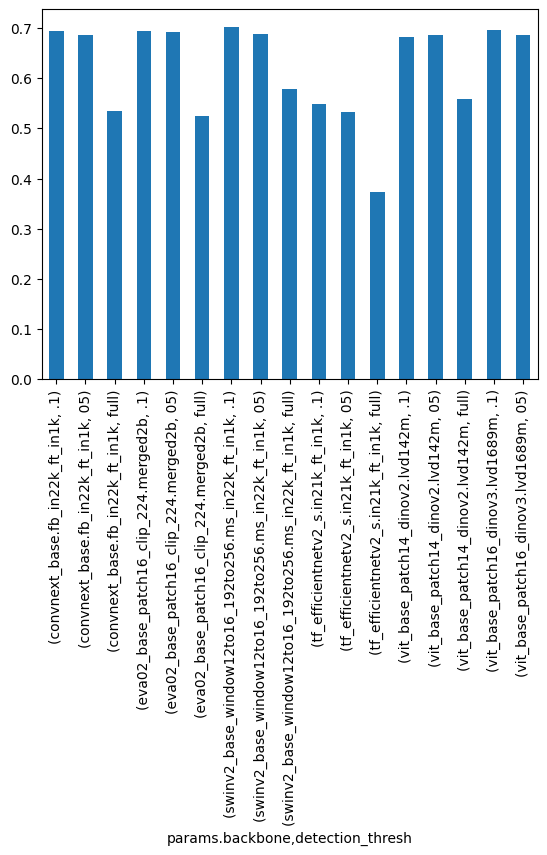

In [28]:
agg_data = df.groupby(['params.backbone', 'detection_thresh'])['metrics.best_val_acc'].mean()
agg_data.plot(kind='bar')

In [29]:
for run_name in df['tags.mlflow.runName'].to_list():
    print(run_name)

dino_v3_.1_fold4
dino_v3_.1_fold3
dino_v3_.1_fold2
dino_v3_.1_fold1
dino_v3_.1_fold0
dino_v3_.05_fold4
dino_v3_.05_fold3
dino_v3_.05_fold2
dino_v3_.05_fold1
dino_v3_.05_fold0
mobilenet_fold4
mobilenet_fold3
mobilenet_fold2
mobilenet_fold1
mobilenet_fold0
eva02_.1_b32_fold4
eva02_.1_b32_fold3
eva02_.1_b32_fold2
eva02_.1_b32_fold1
eva02_.1_b32_fold0
convnext_b32_fold4
convnext_b32_fold3
convnext_b32_fold2
convnext_b32_fold1
convnext_b32_fold0
dinov2_vitb14_reg4_fold4
dinov2_vitb14_reg4_fold3
dinov2_vitb14_reg4_fold2
dinov2_vitb14_reg4_fold1
dinov2_vitb14_reg4_fold0
dinov2_.1_192imgsize_fold4
dinov2_.1_192imgsize_fold3
dinov2_.1_192imgsize_fold2
dinov2_.1_192imgsize_fold1
dinov2_.1_192imgsize_fold0
effnetv2s_full_fold4
effnetv2s_full_fold3
effnetv2s_full_fold2
effnetv2s_full_fold1
effnetv2s_full_fold0
effnetv2s_.1_fold4
effnetv2s_.1_fold3
effnetv2s_.1_fold2
effnetv2s_.1_fold1
effnetv2s_.1_fold0
effnetv2s_.05_fold4
effnetv2s_.05_fold3
effnetv2s_.05_fold2
effnetv2s_.05_fold1
effnetv2s_.05_f

In [30]:
# 3. Reset the index to make index levels into columns
df_plot = agg_data.reset_index()
print("\nDataFrame after reset_index():")
print(df_plot)


DataFrame after reset_index():
                                      params.backbone detection_thresh  \
0                      convnext_base.fb_in22k_ft_in1k               .1   
1                      convnext_base.fb_in22k_ft_in1k               05   
2                      convnext_base.fb_in22k_ft_in1k             full   
3                eva02_base_patch16_clip_224.merged2b               .1   
4                eva02_base_patch16_clip_224.merged2b               05   
5                eva02_base_patch16_clip_224.merged2b             full   
6   swinv2_base_window12to16_192to256.ms_in22k_ft_...               .1   
7   swinv2_base_window12to16_192to256.ms_in22k_ft_...               05   
8   swinv2_base_window12to16_192to256.ms_in22k_ft_...             full   
9                   tf_efficientnetv2_s.in21k_ft_in1k               .1   
10                  tf_efficientnetv2_s.in21k_ft_in1k               05   
11                  tf_efficientnetv2_s.in21k_ft_in1k             full   
12    

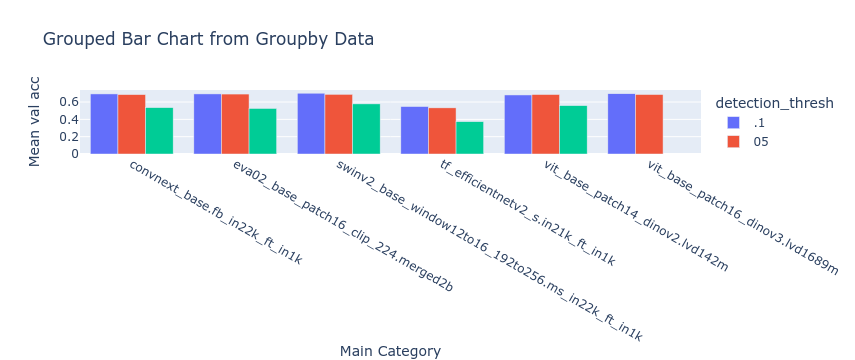

In [31]:


# 4. Plot with Plotly Express
fig = px.bar(
    data_frame=df_plot,
    x="params.backbone",
    y="metrics.best_val_acc",
    color="detection_thresh",
    barmode="group", # Key for grouped bars
    title="Grouped Bar Chart from Groupby Data"
)

# Optional: Further customize the plot
fig.update_layout(xaxis_title="Main Category", yaxis_title="Mean val acc")

# Display the figure
fig.show()


In [32]:
def make_plotly_bars(df, cols):
    for c in cols:
        print(c)
        agg_data = df.groupby(['params.backbone', 'detection_thresh'])[c].mean()
        df_plot = agg_data.reset_index()

        # 4. Plot with Plotly Express
        fig = px.bar(
            data_frame=df_plot,
            x="params.backbone",
            y=c,
            color="detection_thresh",
            barmode="group", # Key for grouped bars
            title=f"Mean for {c}"
        )
    
        # Optional: Further customize the plot
        fig.update_layout(xaxis_title=c, yaxis_title="Mean")
        fig.show()

training_time_m


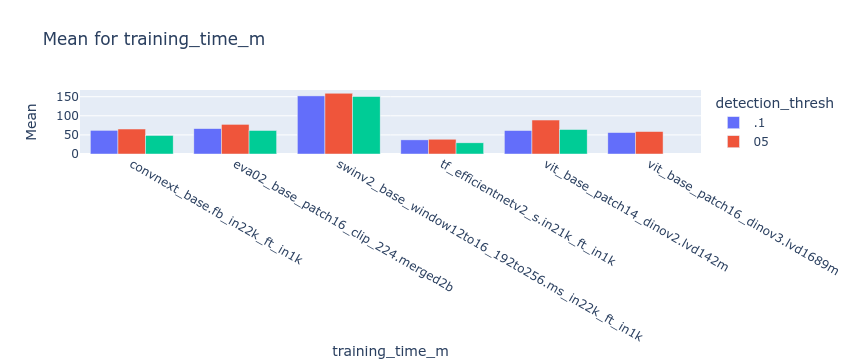

In [33]:
make_plotly_bars(df, ['training_time_m'])

In [34]:
training_time_m

NameError: name 'training_time_m' is not defined

In [ ]:
f1_cols = [c for c in df.columns if 'f1' in c]

In [ ]:
make_plotly_bars(df, f1_cols)

In [ ]:
for c in df.columns:
    if 'f1' in c:
        print(c)

In [ ]:
df['params.augmentation'].value_counts()

In [ ]:
df['params.backbone'].value_counts()

In [ ]:
import plotly.express as px

# 2. Create the bar chart using plotly.express
# Assign the 'LabelText' column to the 'text' parameter for labels on the bars
fig = px.bar(
    runs_df,
    x='tags.mlflow.runName',
    y='metrics.f1_blank',
    # text='LabelText', # Use the 'LabelText' column for the text labels on the bars
    # title="Bar Chart with Custom Labels from a Column"
)

# Optional: Adjust text position and format
# 'text_auto' can be used for automatic text formatting and positioning
# fig = px.bar(df, x='Category', y='Value', text_auto=True, title="Bar Chart with Auto Labels") 
# fig.update_traces(textposition='outside') # Positions labels outside the bars

# 3. Show the figure
fig.show()


In [ ]:
runs_df.columns

In [ ]:
runs_df['tags.mlflow.runName'].unique().tolist()

In [ ]:
runs_df.columns.tolist()

In [ ]:
animal_f1_cols = [x for x in runs_df.columns if 'metrics.f1_' in x]
animal_f1_cols

In [ ]:
animal_labels = [c.split("_")[-1] for c in animal_f1_cols]

In [ ]:
runs_df.shape

In [ ]:
runs_df.head()

In [ ]:
runs_df.columns

In [ ]:
runs_df['tags.mlflow.runName'].to_list()

In [ ]:
# selected_runs = [
#     'convnext_.1',
#      'dinov2_.1',
#     'dino_05_v1',
#     # 'convnext_05_v1', 
#     # 'dinov2_vitb14_0224_1919',
#     'convnext_base_0224_1828',
#     # 'effnetv2s_0224_1503',
#     'dinov2_vits14_v3_0224_1311'
# ]
selected_runs = [x for x in runs_df['tags.mlflow.runName'].to_list() if 'fold' in x]
print(selected_runs)

In [ ]:
selected = runs_df[runs_df['tags.mlflow.runName'].isin(selected_runs)]

In [ ]:
selected

In [ ]:
selected.to_csv(f"{output_dir}/mlflow_data.csv")

In [ ]:
selected["tags.mlflow.runName"].to_list()

In [ ]:
selected['metrics.val_f1_macro']

In [ ]:
import plotly.express as px
import pandas as pd

In [ ]:
runs_df.columns

In [ ]:
f1_metric_cols = [x for x in runs_df.columns if "metrics.f1" in x]

In [ ]:
f1_metric_cols

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

for col in f1_metric_cols:
    print(col)
    runs_df[col].plot(kind='bar')
    plt.show()

    # print(c)
    # col = "metrics.f1_" + c
    
    # fig = px.bar(x=runs_df["tags.mlflow.runName"], y=runs_df[col], title=c)
    # fig.show()
    
    
    
    # fig = make_subplots(
    #     rows=1,
    #     cols=len(select),
    #     subplot_titles=select["tags.mlflow.runName"].tolist(),
    # )
    
    # for idx, (_, row) in enumerate(select.iterrows()):
    #     r = 1
    #     c = idx + 1
        
    #     fig.add_trace(
    #         go.Bar(
    #             x=animal_labels,
    #             y=[row[col] for col in animal_f1_cols],
    #             showlegend=False,
    #         ),
    #         row=r,
    #         col=c,
    #     )
    
    # fig.update_layout(
    #     height=900,
    #     width=1000,
    #     title="F1 per Animal Across Runs",
    # )
    
    # fig.update_yaxes(range=[0, 1])  # recall range
    
    # fig.show()


In [ ]:
runs_df[f1_metric_cols].mean()

In [ ]:
selected[f1_metric_cols].mean()

In [ ]:
for col in f1_metric_cols:
    print(col)
    max_idx = runs_df[col].idxmax()
    model_with_max_score = runs_df.loc[max_idx, "tags.mlflow.runName"]
    print(model_with_max_score)
    print(runs_df.loc[max_idx])
    print('\n')

In [ ]:
runs_df.columns

In [ ]:
from pathlib import Path
import json
import pandas as pd

rows = []
for f in Path("../models").rglob("training_config.json"):
    try:
        cfg = json.loads(f.read_text())
        parts = f.relative_to("../models").parts  # e.g. ('convnext_.1_folds', 'fold_0', 'training_config.json')
        model = parts[0]
        fold = int(parts[1].split("_")[1]) if len(parts) > 2 and "fold" in parts[1] else None
        rows.append({"model": model, "fold": fold, "best_epoch": cfg.get("best_epoch")})
    except (json.JSONDecodeError, KeyError):
        continue

df = pd.DataFrame(rows).sort_values(["model", "fold"]).reset_index(drop=True)
print(df.to_string(index=False))

In [ ]:
df.to_csv('epoch_data.csv')